In [1]:
# ===================================================================
# [노트북 안내] 이 노트북과 JYG.ipynb의 관계
# ===================================================================
#
# 이 노트북(JYG_model_compare.ipynb)은 JYG.ipynb를 그대로 복사한 뒤,
# 전처리 -> TF-IDF -> KMeans(n_clusters=5) 파이프라인은 동일하게 유지하고,
# 그 뒤에 아래 내용을 추가로 붙인 "탐색적 비교/검증용" 노트북임:
#   1) n_clusters=2~5 KMeans 비교 (JYG.ipynb와 동일)
#   2) DBSCAN, GMM 클러스터링 추가 적용 및 KMeans와의 결과 비교
#   3) DBSCAN eps 파라미터를 k-distance elbow plot으로 재검증 및 민감도 분석
#
# 주요 발견 (근거는 각 결과 셀 및 아래 주석 셀 참고):
#   - GMM(n_components=5, covariance_type='diag')은 KMeans와 클러스터 배정이
#     완전히 동일함(ARI=1.0) -> 이 데이터에서는 GMM이 추가 정보를 주지 못함
#   - DBSCAN(eps=1.2, min_samples=3)은 4개 클러스터 + 노이즈 14개(27%)로,
#     KMeans가 찾은 실루엣 음수(오분류 의심) 문서와는 겹치지 않음
#   - eps를 0.02 단위로 촘촘히 바꿔가며 검증한 결과, "클러스터 개수"(4~5개)는
#     비교적 안정적이나 "노이즈 문서 개수"(35~14개)는 파라미터에 매우 민감함
#
# 결론적으로 최종 채택 결과는 JYG.ipynb의 KMeans(n_clusters=5) 클러스터링이며,
# 이 노트북은 그 결과를 다른 방법으로 교차 검증한 보조 자료임.

In [2]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

  
path = r'C:\big21\ml-dev\data\topics'
# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
all_files = glob.glob(os.path.join(path, "*.data"))    
filename_list = []
opinion_text = []


# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    df = pd.read_table(file_,index_col=None, header=0,encoding='latin1')
   
    # 절대경로로 주어진 file 명을 가공. 만일 Linux에서 수행시에는 아래 \\를 / 변경.
    # 맨 마지막 .data 확장자도 제거
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]


    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
    filename_list.append(filename)
    opinion_text.append(df.to_string())


# 파일명 리스트와 파일 내용 리스트를  DataFrame으로 생성
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ..."
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now..."


In [3]:
# 텍스트 전처리(정제, 토큰화, 불용어 제거)에 필요한 라이브러리 불러오기
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

In [4]:
def text_cleaning(text):
   
    # 소문자로 변환
    text = text.lower()
   
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)
   
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
   
    return text.strip()

In [5]:
# 원문 보관 (혹시모를 상황을 대비)
document_df['original_text'] = document_df['opinion_text']

#소문자 / 영문자/공백/여러개공백 처리
document_df['opinion_text'] = document_df['opinion_text'].apply(text_cleaning)

# 토크나이즈(각 단어들로 구분)
document_df['opinion_text'] = document_df['opinion_text'].apply(word_tokenize)

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 불용어 정리
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words and len(word) > 1
    ]
)

# 클렌징 및 토큰화 후, 최종 확인
document_df[['opinion_text']].head()

,opinion_text
0,"[accurate, part, find, garmin, software, provides, accurate, directions, whereever, intend, go, function, accurate, leave, battery, mode, say, stop, cracker, barrell, lunch, play, one, trangle, games, tees, provides, immediate, alternatives, route, online, map, program, inaccurate, blocked, obstacle, used, gps, units, well, gps, built, cars, day, nothing, beats, accuracy, garmin, gps, got, point, point, accuracy, everytime, yet, disappoint, getting, everywhere, accuracy, stars, honest, accurate, review, please, read, aside, every, destination, thrown, accurate, closing, fantastic, gps, nice, features, accurate, directions, plus, always, heard, quirks, gps, accurate, pois, etc, destinatio..."
1,"[room, overly, big, clean, comfortable, beds, great, shower, clean, bathrooms, second, room, smaller, inconvenient, bathroom, layout, least, quieter, able, sleep, large, comfortable, room, wonderful, bathroom, rooms, nice, comfy, bed, clean, bathroom, bathroom, spacious, clean, bathroom, single, sink, large, room, standard, nice, motel, room, like, bathroom, seemed, upgraded, remember, room, quite, small, perfectly, formed, super, bathroom, could, eat, bathroom, floor, clean, bathroom, door, thing, making, bathroom, seem, slightly, larger, bathroom, spotless, nicely, appointed, rooms, exceptionally, clean, also, bathrooms, bathroom, clean, bed, comfy, provide, great, aveda, products, bat..."
2,"[plugged, usb, hub, computer, charge, battery, charging, cord, design, clever, paged, tru, page, book, one, page, time, get, chapter, chapter, see, excited, low, battery, time, took, get, user, replaceable, battery, unless, buy, extended, warranty, year, pay, plus, shipping, send, device, amazon, kindle, replaced, battery, changed, fact, kindle, sd, card, capability, battery, user, serviceable, issue, things, like, buttons, made, easy, accidentally, turn, pages, separate, cursor, side, could, select, lines, sometimes, hard, see, occasionally, awkward, menus, case, practically, forced, remove, use, sometimes, pulled, battery, door, issue, battery, door, opening, thus, solved, amazon, went..."
3,"[short, battery, life, moved, gb, love, ipod, except, battery, life, long, battery, scratch, resistant, battery, drains, even, use, wonder, battery, seems, drain, using, even, sliding, top, control, button, shutting, great, car, light, portable, good, quality, long, battery, scratch, resistant, lies, mature, ipod, many, steps, wiser, able, one, year, old, ipod, gains, many, incremental, improvements, including, brighter, screen, better, video, battery, life, probably, appealing, aspect, tantalizing, price, points, gb, version, huge, gb, version, gb, better, battery, life, rated, battery, dummie, proof, love, color, ipod, battery, life, amazing, definitely, need, get, case, wanted, get, n..."
4,"[ghz, fsb, cpu, glossy, display, cell, wh, li, ion, battery, mention, asus, sell, spare, cell, li, ion, battery, also, features, cpu, cell, wh, li, ion, battery, mp, webcam, cell, wh, li, ion, battery, whopping, realistic, battery, numbers, battery, life, using, wifi, email, word, processing, youtube, web, surfing, eee, super, hybrid, engine, utility, lets, users, overclock, underclock, eee, pc, boost, performance, provide, better, battery, life, depending, immediate, requirements, things, like, point, must, push, micro, sized, right, angle, end, ac, adapter, snaps, place, battery, may, charge, addition, ac, adapter, get, quite, hot, actively, charging, battery, asus, clearly, mentions, ..."


In [6]:
#단어 빈도수 체크에 대한 함수

from collections import Counter
from nltk.tokenize import word_tokenize

for index, row in document_df.iterrows():
   
    # 클렌징된 텍스트 가져오기
    text = row['opinion_text']
   
    # 단어 빈도 계산
    word_counts = Counter(text)
   
    print(f"===== {row['filename']} =====")
    print(word_counts.most_common(30))
    print()

===== accuracy_garmin_nuvi_255W_gps =====
[('accurate', 48), ('accuracy', 13), ('gps', 12), ('directions', 11), ('easy', 9), ('map', 7), ('use', 7), ('used', 6), ('point', 6), ('time', 6), ('speed', 6), ('garmin', 5), ('destination', 5), ('always', 5), ('good', 5), ('unit', 5), ('turn', 5), ('one', 4), ('stars', 4), ('nice', 4), ('pretty', 4), ('arrival', 4), ('maps', 4), ('street', 4), ('tell', 4), ('roads', 4), ('find', 3), ('route', 3), ('inaccurate', 3), ('well', 3)]

===== bathroom_bestwestern_hotel_sfo =====
[('bathroom', 79), ('room', 36), ('clean', 23), ('bathrooms', 12), ('rooms', 12), ('nice', 12), ('small', 12), ('large', 10), ('sink', 10), ('also', 9), ('comfortable', 8), ('shower', 8), ('bed', 7), ('door', 7), ('good', 7), ('big', 6), ('well', 6), ('plenty', 6), ('quite', 5), ('little', 5), ('adequate', 5), ('enough', 5), ('hotel', 5), ('us', 5), ('space', 5), ('beds', 4), ('thing', 4), ('toilet', 4), ('basin', 4), ('one', 4)]

===== battery-life_amazon_kindle =====
[('bat

In [7]:
# 표제어 추출(lemmatization)을 위한 준비: 단/복수형, 활용형 단어를 원형으로 통일
import string
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

# 구두점을 지우기 위한 매핑 테이블 (문자 -> None)
remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 토큰 리스트의 각 단어를 표제어(원형)로 변환
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# 소문자화 + 구두점 제거 + 토큰화 + 표제어 추출을 한 번에 수행하는 함수
# TfidfVectorizer의 tokenizer 파라미터로 사용됨
def LemNormalize(text):
    text_new = text.lower().translate(remove_punct_dict)
    word_tokens = nltk.word_tokenize(text_new)
    return LemTokens(word_tokens)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mega\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
# 원문(original_text)을 LemNormalize로 전처리하며 TF-IDF 벡터로 변환
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,   # 토큰화 방식으로 위에서 만든 LemNormalize 사용
    stop_words='english',     # 영어 불용어 자동 제거
    ngram_range=(1, 2),       # 단어 1개(uni-gram)와 2개 묶음(bi-gram) 모두 특징으로 사용
    min_df=0.05,               # 전체 문서의 5% 미만에서만 등장하는 단어는 제외
    max_df=0.85                # 전체 문서의 85% 이상에서 등장하는(너무 흔한) 단어는 제외
)

feature_vect = tfidf_vect.fit_transform(document_df['original_text'])

In [9]:
# 최종 클러스터링: KMeans로 5개 그룹으로 분류
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)

# 문서별로 배정된 클러스터 번호를 컬럼으로 추가
document_df['cluster_label'] = km_cluster.labels_

# 같은 클러스터끼리 모아서 확인
document_df.sort_values(by='cluster_label')[['filename', 'cluster_label']]

,filename,cluster_label
28,price_holiday_inn_london,0
23,navigation_amazon_kindle,0
5,buttons_amazon_kindle,0
10,eyesight-issues_amazon_kindle,0
27,price_amazon_kindle,0
12,fonts_amazon_kindle,0
30,rooms_bestwestern_hotel_sfo,1
31,rooms_swissotel_chicago,1
24,parking_bestwestern_hotel_sfo,1
32,room_holiday_inn_london,1


In [10]:
# 클러스터별 핵심 키워드와 소속 파일 확인 (군집의 의미 해석)
feature_names = tfidf_vect.get_feature_names_out()
cluster_centers = km_cluster.cluster_centers_

for cluster_num in range(km_cluster.n_clusters):
    print(f"===== Cluster {cluster_num} =====")

    # 중심(centroid)에서 TF-IDF 값이 높은 상위 10개 단어 = 이 군집을 대표하는 키워드
    top_idx = cluster_centers[cluster_num].argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_idx]
    print("핵심 키워드:", top_terms)

    # 이 군집에 속한 문서(파일) 목록
    filenames = document_df[document_df['cluster_label'] == cluster_num]['filename'].values
    print("소속 파일:", list(filenames))
    print()

===== Cluster 0 =====
핵심 키워드: ['price', 'kindle', 'page', 'button', 'font', 'book', 'eye', 'navigation', 'font size', 'easy']
소속 파일: ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'fonts_amazon_kindle', 'navigation_amazon_kindle', 'price_amazon_kindle', 'price_holiday_inn_london']

===== Cluster 1 =====
핵심 키워드: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'clean', 'bathroom', 'parking', 'room service']
소속 파일: ['bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'location_bestwestern_hotel_sfo', 'location_holiday_inn_london', 'parking_bestwestern_hotel_sfo', 'rooms_bestwestern_hotel_sfo', 'rooms_swissotel_chicago', 'room_holiday_inn_london', 'service_bestwestern_hotel_sfo', 'service_holiday_inn_london', 'service_swissotel_hotel_chicago', 'staff_bestwestern_hotel_sfo', 'staff_swissotel_chicago']

===== Cluster 2 =====
핵심 키워드: ['screen', 'keyboard', 'direction', 'map', 'voice', 'speed limit', 'accura

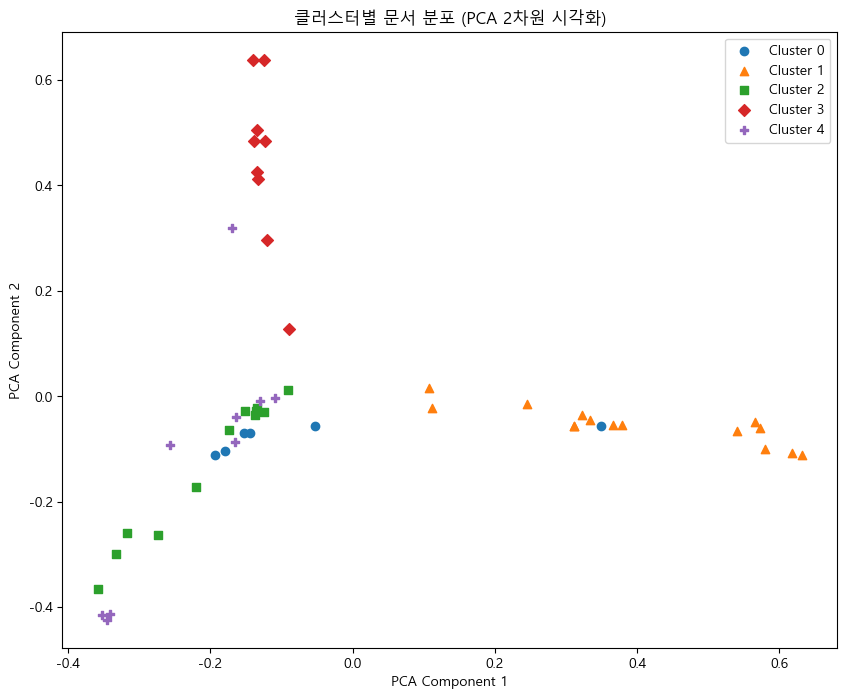

In [11]:
# PCA로 2차원 축소 후, 클러스터가 실제로 잘 나뉘었는지 시각화
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 그래프에 한글이 깨지지 않도록 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# PCA는 밀집 행렬(dense)만 입력받으므로, 희소 행렬인 feature_vect를 dense로 변환
pca = PCA(n_components=2, random_state=0)
pca_vect = pca.fit_transform(feature_vect.toarray())

# 시각화를 위해 축소된 2개 좌표값을 문서별로 저장
document_df['pca_x'] = pca_vect[:, 0]
document_df['pca_y'] = pca_vect[:, 1]

plt.figure(figsize=(10, 8))

markers = ['o', '^', 's', 'D', 'P']
for cluster_num in range(km_cluster.n_clusters):
    # 클러스터별로 점 모양을 다르게 해서 산점도에 표시
    cluster_data = document_df[document_df['cluster_label'] == cluster_num]
    plt.scatter(
        cluster_data['pca_x'], cluster_data['pca_y'],
        marker=markers[cluster_num % len(markers)],
        label=f'Cluster {cluster_num}'
    )

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('클러스터별 문서 분포 (PCA 2차원 시각화)')
plt.legend()
plt.show()

In [12]:
# n_clusters를 2, 3, 4, 5로 바꿔가며 클러스터링 결과 비교
k_list = [2, 3, 4, 5]
km_results = {}  # k별 학습된 KMeans 모델을 저장해서 다음 셀(산점도)에서 재사용

for k in k_list:
    km = KMeans(n_clusters=k, max_iter=10000, random_state=0)
    km.fit(feature_vect)
    km_results[k] = km

    print(f"########## n_clusters={k} ##########")
    centers = km.cluster_centers_
    for cluster_num in range(k):
        # 클러스터 중심에서 TF-IDF 값이 높은 상위 10개 단어 = 핵심 키워드
        top_idx = centers[cluster_num].argsort()[::-1][:10]
        top_terms = [feature_names[i] for i in top_idx]
        # 이 클러스터에 속한 문서(파일) 목록
        filenames = document_df.loc[km.labels_ == cluster_num, 'filename'].values
        print(f"[Cluster {cluster_num}] 키워드: {top_terms}")
        print(f"           파일: {list(filenames)}")
    print()

########## n_clusters=2 ##########
[Cluster 0] 키워드: ['screen', 'battery', 'performance', 'keyboard', 'mileage', 'battery life', 'life', 'kindle', 'direction', 'video']
           파일: ['accuracy_garmin_nuvi_255W_gps', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'buttons_amazon_kindle', 'directions_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle', 'features_windows7', 'fonts_amazon_kindle', 'gas_mileage_toyota_camry_2007', 'keyboard_netbook_1005ha', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'performance_honda_accord_2008', 'performance_netbook_1005ha', 'price_amazon_kindle', 'quality_toyota_camry_2007', 'satellite_garmin_nuvi_255W_gps', 'screen_garmin_nuvi_255W_gps', 'screen_ipod_nano_8gb', 'screen_netbook_1005ha', 'size_asus_netbook_1005ha', 'sound_ipod_nano_8gb', 'speed_garmin_nuvi_255W_gps', 'speed_windows7', 'transmission_toyota_camry_2007', 'updates_garmin_nuvi_255W_gps', 'video_ipod_

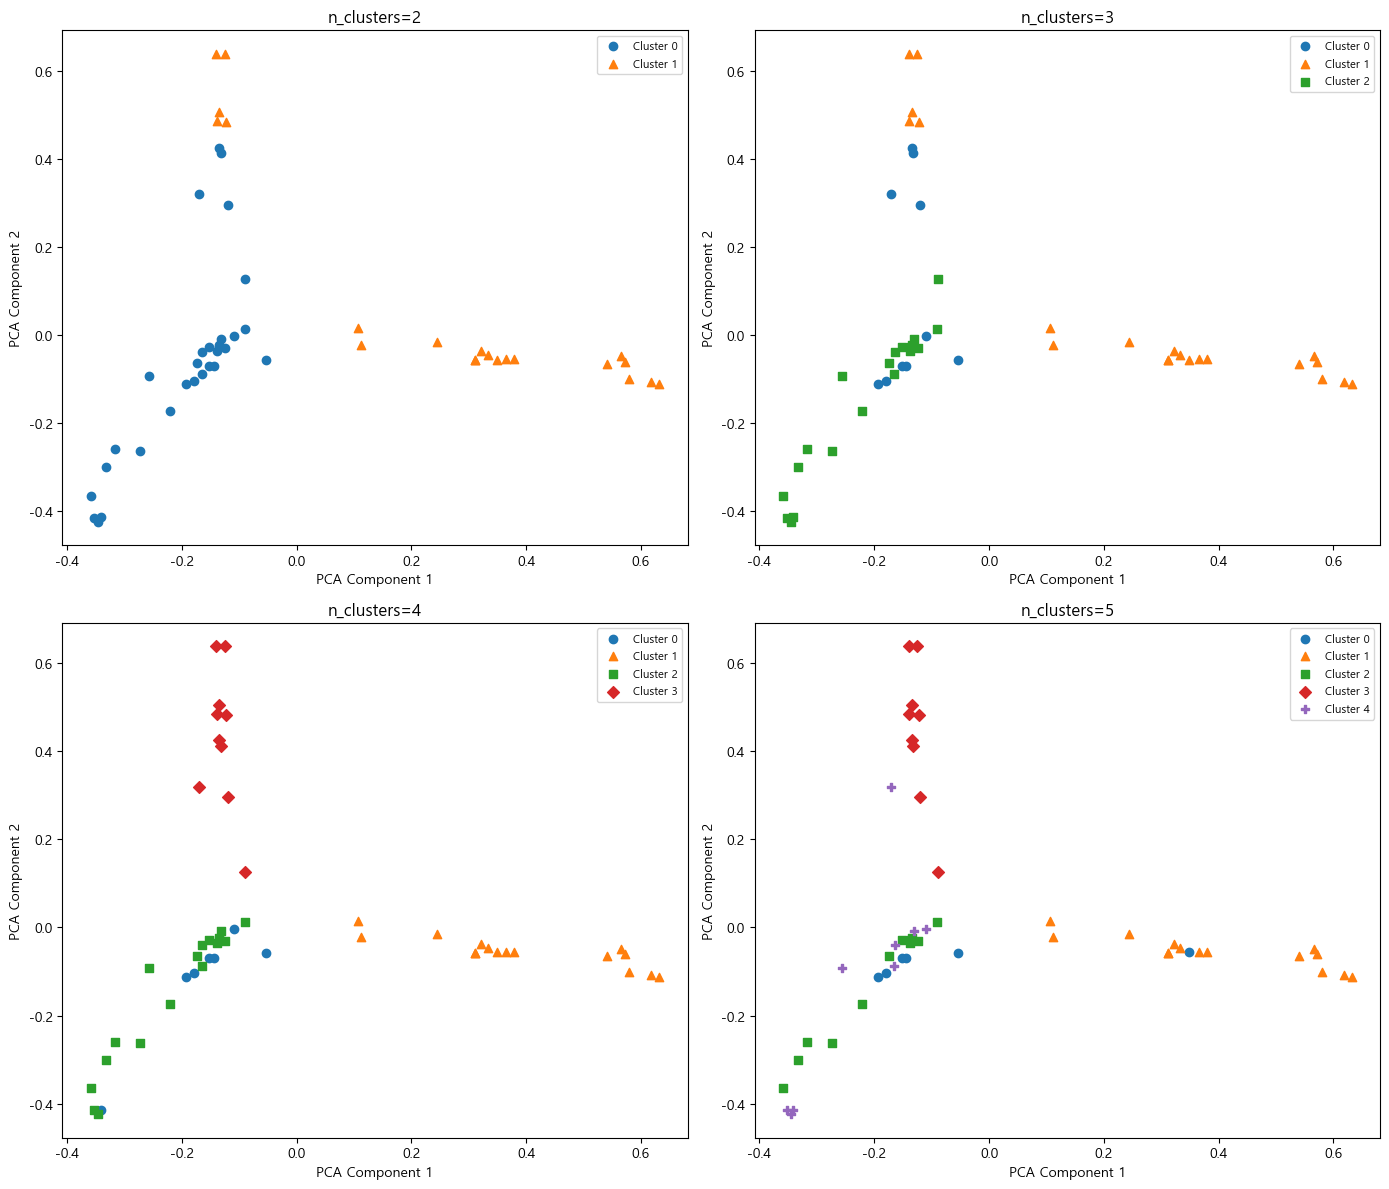

In [13]:
# n_clusters=2,3,4,5 각각의 PCA 2차원 산점도를 한눈에 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
markers = ['o', '^', 's', 'D', 'P']

for ax, k in zip(axes.flatten(), k_list):
    km = km_results[k]
    for cluster_num in range(k):
        # 같은 PCA 좌표(pca_vect)를 그대로 써서, k에 따라 군집 색만 다르게 표시
        mask = km.labels_ == cluster_num
        ax.scatter(
            pca_vect[mask, 0], pca_vect[mask, 1],
            marker=markers[cluster_num % len(markers)],
            label=f'Cluster {cluster_num}'
        )
    ax.set_title(f'n_clusters={k}')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# DBSCAN 클러스터링: 밀도 기반이라 k(군집 개수)를 미리 정하지 않고, 어디에도 안 묶이는 문서는 노이즈(-1)로 분류
from sklearn.cluster import DBSCAN
import numpy as np

# eps, min_samples는 각 문서의 4번째 최근접 이웃까지의 거리 분포(약 1.0~1.36)를 참고해 실험적으로 정함
dbscan = DBSCAN(eps=1.2, min_samples=3, metric='euclidean')
dbscan_labels = dbscan.fit_predict(feature_vect)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN 결과: 클러스터 {n_clusters_db}개, 노이즈(어느 클러스터에도 안 묶인 문서) {n_noise}개\n")

for cluster_num in sorted(set(dbscan_labels)):
    label_name = "Noise" if cluster_num == -1 else f"Cluster {cluster_num}"
    filenames = document_df.loc[dbscan_labels == cluster_num, 'filename'].values

    print(f"[{label_name}]")
    if cluster_num != -1:
        # DBSCAN은 centroid가 없으므로, 클러스터에 속한 문서들의 평균 TF-IDF로 핵심 키워드를 대신 확인
        centroid = np.asarray(feature_vect[dbscan_labels == cluster_num].mean(axis=0)).ravel()
        top_idx = centroid.argsort()[::-1][:10]
        top_terms = [feature_names[i] for i in top_idx]
        print(f"  키워드: {top_terms}")
    print(f"  파일: {list(filenames)}")
    print()

DBSCAN 결과: 클러스터 4개, 노이즈(어느 클러스터에도 안 묶인 문서) 14개

[Noise]
  파일: ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'features_windows7', 'fonts_amazon_kindle', 'free_bestwestern_hotel_sfo', 'gas_mileage_toyota_camry_2007', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'parking_bestwestern_hotel_sfo', 'quality_toyota_camry_2007', 'satellite_garmin_nuvi_255W_gps', 'speed_windows7', 'transmission_toyota_camry_2007', 'updates_garmin_nuvi_255W_gps']

[Cluster 0]
  키워드: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'price', 'bathroom', 'clean', 'room service']
  파일: ['bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'food_swissotel_chicago', 'location_bestwestern_hotel_sfo', 'location_holiday_inn_london', 'price_amazon_kindle', 'price_holiday_inn_london', 'rooms_bestwestern_hotel_sfo', 'rooms_swissotel_chicago', 'room_holiday_inn_london', 'service_bestwestern_hotel_sfo', 'service_holiday_inn_london', 'service_swissotel_hotel_chicago', 'staff_bestwestern

In [15]:
# GMM(Gaussian Mixture) 클러스터링: 각 문서가 어느 군집에 속할 확률이 가장 높은지를 기준으로 분류
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# covariance_type='diag': 문서 수(51)보다 차원(4610)이 훨씬 커서 'full'은 공분산 행렬이 특이(singular)해짐
gmm = GaussianMixture(n_components=5, covariance_type='diag', random_state=0, max_iter=500)
gmm_labels = gmm.fit_predict(feature_vect.toarray())  # GMM은 밀집 행렬만 입력받음

for cluster_num in range(gmm.n_components):
    top_idx = gmm.means_[cluster_num].argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_idx]
    filenames = document_df.loc[gmm_labels == cluster_num, 'filename'].values

    print(f"[Cluster {cluster_num}]")
    print(f"  키워드: {top_terms}")
    print(f"  파일: {list(filenames)}")
    print()

# KMeans와 클러스터 배정이 얼마나 일치하는지 확인 (1.0 = 완전히 동일)
print("KMeans와 GMM의 일치도(ARI):", round(adjusted_rand_score(km_cluster.labels_, gmm_labels), 4))

[Cluster 0]
  키워드: ['price', 'kindle', 'page', 'button', 'font', 'book', 'eye', 'navigation', 'font size', 'easy']
  파일: ['buttons_amazon_kindle', 'eyesight-issues_amazon_kindle', 'fonts_amazon_kindle', 'navigation_amazon_kindle', 'price_amazon_kindle', 'price_holiday_inn_london']

[Cluster 1]
  키워드: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'clean', 'bathroom', 'parking', 'room service']
  파일: ['bathroom_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'location_bestwestern_hotel_sfo', 'location_holiday_inn_london', 'parking_bestwestern_hotel_sfo', 'rooms_bestwestern_hotel_sfo', 'rooms_swissotel_chicago', 'room_holiday_inn_london', 'service_bestwestern_hotel_sfo', 'service_holiday_inn_london', 'service_swissotel_hotel_chicago', 'staff_bestwestern_hotel_sfo', 'staff_swissotel_chicago']

[Cluster 2]
  키워드: ['screen', 'keyboard', 'direction', 'map', 'voice', 'speed limit', 'accurate', 'speed', 'satellite', 'limit']

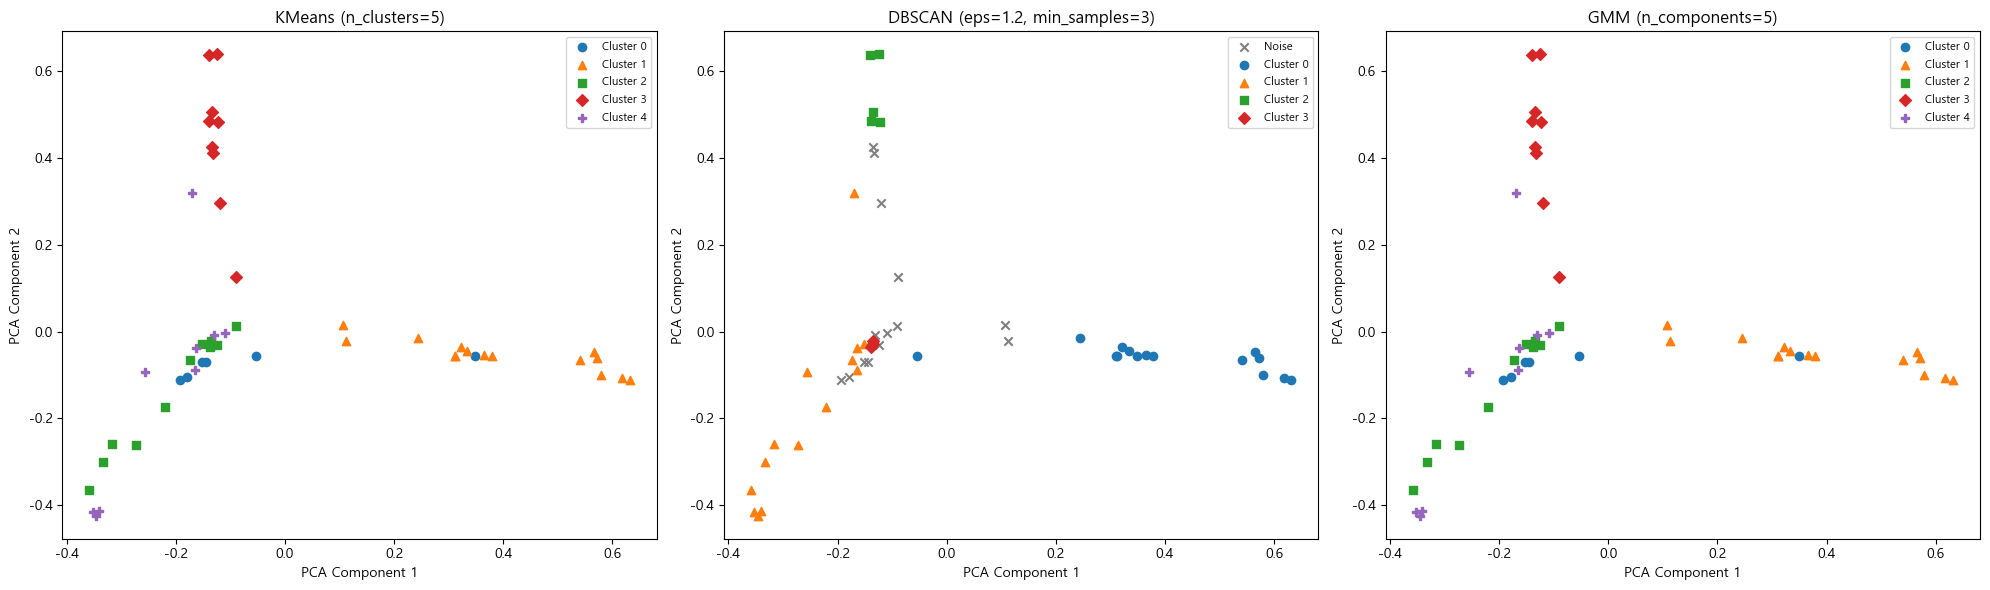

In [16]:
# KMeans / DBSCAN / GMM 3개 모델의 클러스터링 결과를 같은 PCA 좌표 위에서 비교
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
markers = ['o', '^', 's', 'D', 'P']

# KMeans
for cluster_num in range(km_cluster.n_clusters):
    mask = km_cluster.labels_ == cluster_num
    axes[0].scatter(pca_vect[mask, 0], pca_vect[mask, 1], marker=markers[cluster_num % len(markers)], label=f'Cluster {cluster_num}')
axes[0].set_title('KMeans (n_clusters=5)')

# DBSCAN (노이즈는 회색 x로 별도 표시)
for cluster_num in sorted(set(dbscan_labels)):
    mask = dbscan_labels == cluster_num
    if cluster_num == -1:
        axes[1].scatter(pca_vect[mask, 0], pca_vect[mask, 1], marker='x', color='gray', label='Noise')
    else:
        axes[1].scatter(pca_vect[mask, 0], pca_vect[mask, 1], marker=markers[cluster_num % len(markers)], label=f'Cluster {cluster_num}')
axes[1].set_title('DBSCAN (eps=1.2, min_samples=3)')

# GMM
for cluster_num in range(gmm.n_components):
    mask = gmm_labels == cluster_num
    axes[2].scatter(pca_vect[mask, 0], pca_vect[mask, 1], marker=markers[cluster_num % len(markers)], label=f'Cluster {cluster_num}')
axes[2].set_title('GMM (n_components=5)')

for ax in axes:
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# ===================================================================
# [참고] DBSCAN 결과 해석 정리 — 보고서 참조용
# ===================================================================
#
# DBSCAN(eps=1.2, min_samples=3) 결과: 클러스터 4개 + 노이즈 14개(전체 51개 중 약 27%)
#
# 1) 유의미하다고 볼 수 있는 부분
#    - KMeans/GMM은 모든 문서를 무조건 5개 그룹 중 하나에 강제로 배정하지만,
#      DBSCAN은 "이 문서는 어느 그룹에도 뚜렷이 속하지 않는다"는 판단 자체를
#      결과로 내놓을 수 있음. 이는 KMeans/GMM에는 없는 정보임.
#    - GPS 관련 클러스터(Cluster 3: direction, voice, accurate, gps, map)가
#      단 3개 문서(accuracy_garmin_nuvi_255W_gps, directions_garmin_nuvi_255W_gps,
#      voice_garmin_nuvi_255W_gps)로만 구성되어, KMeans의 GPS 클러스터(12개 파일,
#      screen/keyboard 등 다른 주제 섞임)보다 훨씬 순수하게(주제가 덜 섞인 채로) 분리됨.
#
# 2) 아직 확정하기 어려운 부분
#    - eps=1.2는 "문서별 4번째 최근접 이웃 거리 분포(약 1.0~1.36)"를 참고해
#      실험적으로 정한 값으로, k-distance elbow plot 등으로 엄밀히 검증한 값이
#      아님. eps를 조금만 바꿔도(0.95~1.3 사이에서 테스트) 클러스터 개수가
#      1~14개까지 크게 요동쳤고, 노이즈로 분류되는 문서 목록도 함께 바뀔 가능성이 큼.
#    - KMeans 기준 실루엣 점수가 음수(오분류 의심)였던 문서
#      (performance_honda_accord_2008, price_holiday_inn_london) 2개는
#      DBSCAN 노이즈 목록(14개)과 교집합이 없었음(직접 대조 확인, 코드는 대화 로그 참고).
#      즉 "KMeans가 애매하다고 본 문서"와 "DBSCAN이 노이즈로 본 문서"가 서로 다른
#      대상을 가리켜서, DBSCAN의 노이즈 판정이 다른 방법으로도 교차 검증된
#      강건한(robust) 신호라고 보기는 아직 이름.
#
# 3) 결론
#    - DBSCAN은 "일부 리뷰는 뚜렷한 주제 없이 여러 내용이 섞여 있을 수 있다"는
#      가설을 뒷받침하는 참고 자료로는 유의미하지만, 지금 파라미터(eps=1.2,
#      min_samples=3)로 나온 노이즈 14개를 "확정된 이상치 목록"으로 보고서에
#      그대로 싣는 것은 과대해석임.
#    - 후속 작업으로는 (a) k-distance elbow plot으로 eps를 재검증하고
#      민감도를 확인하는 것, (b) 노이즈로 분류된 문서 원문을 직접 읽어
#      정성적으로 검토하는 것, (c) 최종 리포트에서 노이즈 문서를
#      "미분류/기타" 그룹으로 별도 보고할지, 아니면 KMeans 배정을 그대로
#      사용할지 실무적으로 결정하는 것이 필요함.

k-distance elbow 지점: 15번째 문서, eps ~ 1.0655
(참고: 위 DBSCAN 셀에서 실험적으로 정했던 값은 eps=1.2)


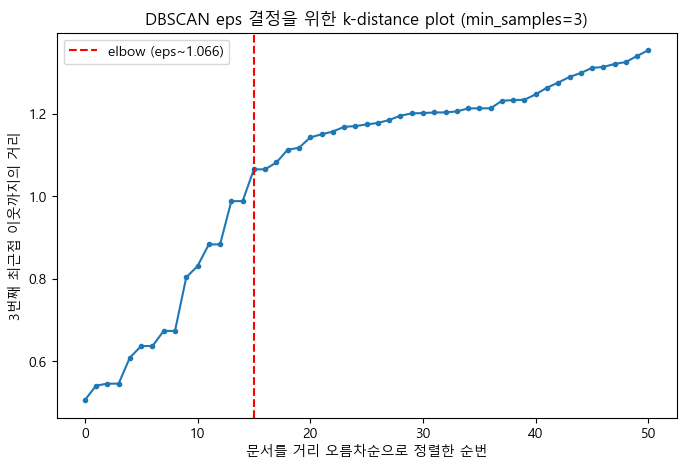

In [18]:
# DBSCAN eps 파라미터를 k-distance elbow plot으로 엄밀하게 재검증
from sklearn.neighbors import NearestNeighbors

min_samples_for_plot = 3  # 위 DBSCAN 셀과 동일한 min_samples 기준

# 문서별로 min_samples번째 최근접 이웃까지의 거리를 구해서 오름차순 정렬
nn = NearestNeighbors(n_neighbors=min_samples_for_plot).fit(feature_vect)
distances, _ = nn.kneighbors(feature_vect)
k_dist_sorted = np.sort(distances[:, -1])

# elbow(꺾이는 지점) 탐색: 그래프의 첫 점과 끝 점을 잇는 직선에서
# 수직 거리가 가장 먼 점을 elbow로 판단 (kneed 라이브러리 없이 쓰는 표준적인 방법)
def find_elbow(y):
    x = np.arange(len(y))
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line_vec = (p2 - p1) / np.linalg.norm(p2 - p1)
    perp_dists = []
    for i in range(len(y)):
        p = np.array([x[i], y[i]]) - p1
        proj = np.dot(p, line_vec) * line_vec
        perp_dists.append(np.linalg.norm(p - proj))
    return int(np.argmax(perp_dists))

elbow_idx = find_elbow(k_dist_sorted)
elbow_eps = k_dist_sorted[elbow_idx]
print(f"k-distance elbow 지점: {elbow_idx}번째 문서, eps ~ {elbow_eps:.4f}")
print(f"(참고: 위 DBSCAN 셀에서 실험적으로 정했던 값은 eps=1.2)")

plt.figure(figsize=(8, 5))
plt.plot(k_dist_sorted, marker='o', markersize=3)
plt.axvline(elbow_idx, color='red', linestyle='--', label=f'elbow (eps~{elbow_eps:.3f})')
plt.xlabel('문서를 거리 오름차순으로 정렬한 순번')
plt.ylabel(f'{min_samples_for_plot}번째 최근접 이웃까지의 거리')
plt.title(f'DBSCAN eps 결정을 위한 k-distance plot (min_samples={min_samples_for_plot})')
plt.legend()
plt.show()

In [19]:
# eps 민감도 검증: elbow 근처 좁은 구간에서 eps를 조금씩 바꿔가며
# 클러스터 개수·노이즈 개수가 얼마나 안정적인지(혹은 불안정한지) 확인
print(f"{'eps':>6} | {'min_samples=3':>20} | {'min_samples=4':>20} | {'min_samples=5':>20}")
for eps in np.arange(1.00, 1.30, 0.02):
    row = [f'{eps:.2f}']
    for ms in [3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=ms).fit(feature_vect)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        row.append(f'clusters={n_clusters}, noise={n_noise}')
    print(f"{row[0]:>6} | {row[1]:>20} | {row[2]:>20} | {row[3]:>20}")

   eps |        min_samples=3 |        min_samples=4 |        min_samples=5
  1.00 | clusters=5, noise=35 | clusters=1, noise=47 | clusters=0, noise=51
  1.02 | clusters=5, noise=35 | clusters=1, noise=47 | clusters=0, noise=51
  1.04 | clusters=5, noise=35 | clusters=1, noise=47 | clusters=0, noise=51
  1.06 | clusters=4, noise=35 | clusters=1, noise=44 | clusters=0, noise=51
  1.08 | clusters=5, noise=31 | clusters=1, noise=44 | clusters=0, noise=51
  1.10 | clusters=5, noise=28 | clusters=2, noise=39 | clusters=1, noise=44
  1.12 | clusters=5, noise=26 | clusters=3, noise=35 | clusters=1, noise=44
  1.14 | clusters=5, noise=26 | clusters=3, noise=35 | clusters=1, noise=44
  1.16 | clusters=5, noise=22 | clusters=4, noise=29 | clusters=1, noise=42
  1.18 | clusters=4, noise=18 | clusters=4, noise=21 | clusters=2, noise=32
  1.20 | clusters=4, noise=14 | clusters=3, noise=19 | clusters=3, noise=27
  1.22 |  clusters=3, noise=8 | clusters=3, noise=14 | clusters=3, noise=15


  1.24 |  clusters=2, noise=7 | clusters=3, noise=10 | clusters=3, noise=14
  1.26 |  clusters=2, noise=7 |  clusters=3, noise=8 | clusters=3, noise=12
  1.28 |  clusters=1, noise=6 |  clusters=1, noise=6 |  clusters=1, noise=8
  1.30 |  clusters=1, noise=5 |  clusters=1, noise=5 |  clusters=1, noise=5


In [20]:
# ===================================================================
# [참고] eps 재검증 결과 정리 — 위 "DBSCAN 결과 해석 정리"에 이어지는 후속 검증
# ===================================================================
#
# k-distance elbow plot으로 구한 eps:
#   - min_samples=3 -> eps ~ 1.07
#   - min_samples=4 -> eps ~ 1.16
#   - min_samples=5 -> eps ~ 1.18
#   (참고로 처음 DBSCAN 셀에서 실험적으로 골랐던 값은 eps=1.2로, elbow 값들과
#    크게 어긋나지는 않음)
#
# 다만 eps를 1.00~1.30 사이에서 0.02 단위로 촘촘히 바꿔가며 확인해보니:
#   - "클러스터 개수"는 min_samples=3 기준 대체로 4~5개 사이를 오가며,
#     이는 KMeans/GMM이 찾은 5개 주제(Kindle/호텔/GPS/자동차/배터리)와
#     대략 비슷한 규모라 어느 정도 안정적이라고 볼 수 있음.
#   - 반면 "노이즈로 분류되는 문서 개수"는 같은 구간에서 35개→14개까지
#     eps 값에 따라 크게 흔들림. 즉 "몇 개의 주제가 있는가"는 비교적
#     안정적으로 재현되지만, "구체적으로 어떤 문서가 노이즈(이상치)인가"는
#     eps 선택에 따라 계속 바뀌는, 신뢰하기 어려운 결과임.
#
# 결론:
#   - eps=1.2는 k-distance elbow 근처 값이라 "근거 없이 아무렇게나 고른 값"은
#     아니었음이 확인됨.
#   - 하지만 이 데이터셋(51개 문서, TF-IDF 4600여 차원의 희소 공간)에서는
#     DBSCAN이 "안정적인 eps 구간(plateau)"을 갖지 못하고, 노이즈 판정이
#     파라미터에 민감하게 반응하는 구조적 한계가 있음. 따라서 보고서에는
#     "DBSCAN은 대략 4~5개의 주제 군집이 있다는 것은 KMeans/GMM과 일치되게
#     보여주지만, 노이즈로 분류된 특정 문서 목록은 파라미터 민감도가 높아
#     확정적 근거로 사용하기 어렵다"고 기술하는 것이 정확함.